--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        500 non-null    int64  
 1   Age               500 non-null    int64  
 2   Annual_Income_k   500 non-null    float64
 3   Spending_Score    500 non-null    float64
 4   Membership_Years  500 non-null    int64  
 5   Device_Type       500 non-null    object 
dtypes: float64(2), int64(3), object(1)
memory usage: 23.6+ KB
None

--- Descriptive Statistics ---
       CustomerID     Age  Annual_Income_k  Spending_Score  Membership_Years
count      500.00  500.00           500.00          500.00            500.00
mean     10250.50   41.28            64.84           57.73              4.99
std        144.48   13.39            19.75           16.71              2.52
min      10001.00   18.00            11.10            5.00              1.00
25%    

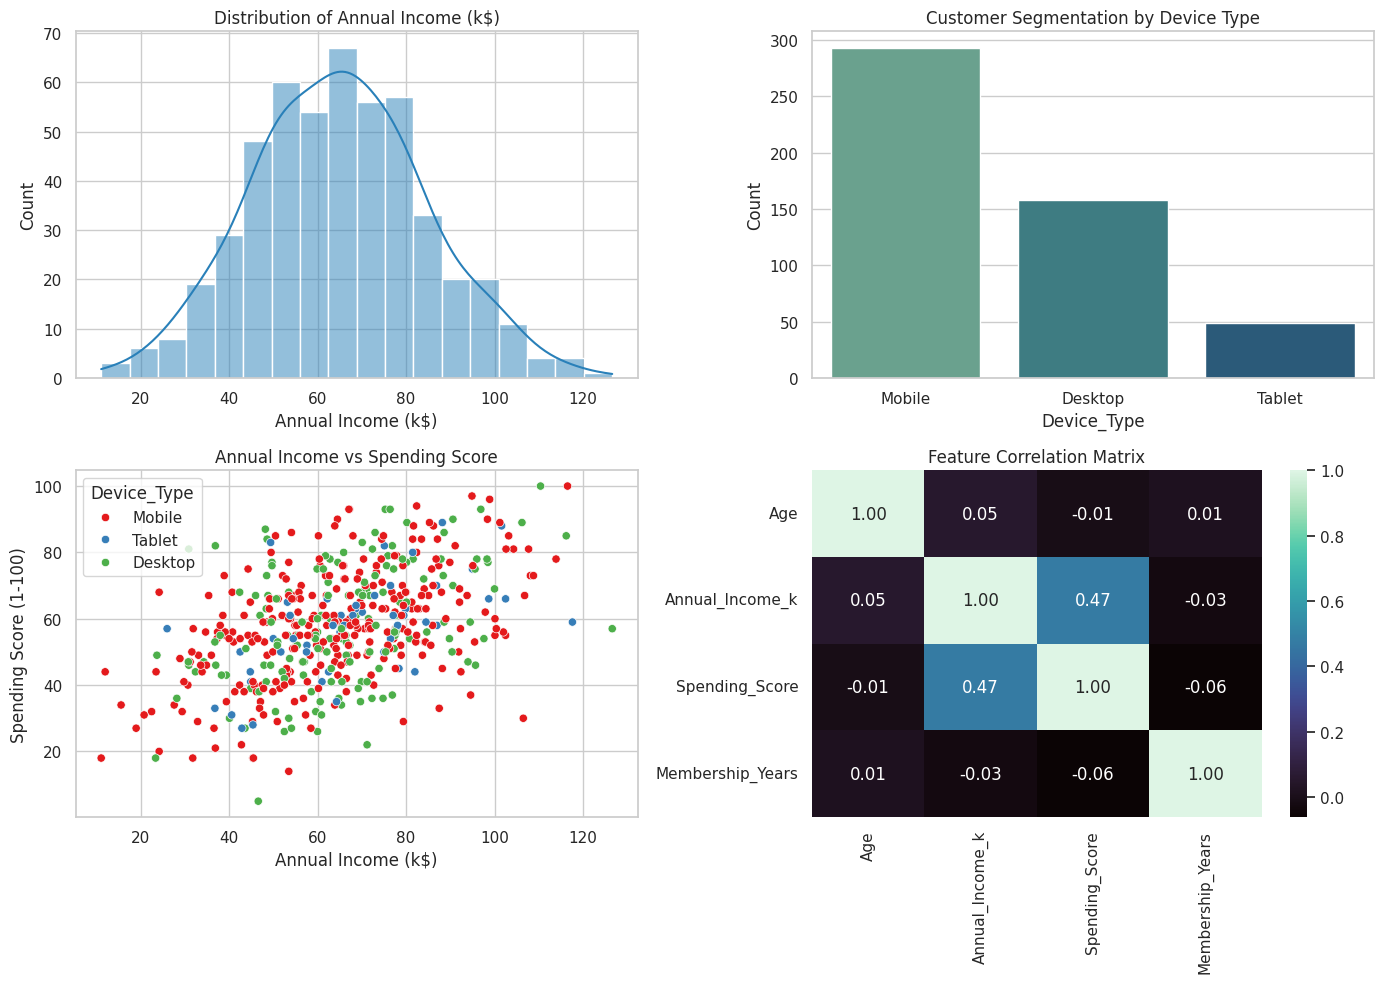

Plots generated and saved as eda_insights.png


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# 1. Generate Realistic E-Commerce / Customer Behavior Dataset
np.random.seed(42)
n_records = 500

age = np.random.randint(18, 65, size=n_records)
annual_income_k = np.random.normal(loc=65, scale=20, size=n_records).round(1)
spending_score = np.clip(
    0.4 * annual_income_k + np.random.normal(30, 15, size=n_records), 1, 100
).round(0)
membership_years = np.random.randint(1, 10, size=n_records)
device = np.random.choice(["Mobile", "Desktop", "Tablet"], p=[0.6, 0.3, 0.1], size=n_records)

df = pd.DataFrame({
    "CustomerID": range(10001, 10001 + n_records),
    "Age": age,
    "Annual_Income_k": annual_income_k,
    "Spending_Score": spending_score,
    "Membership_Years": membership_years,
    "Device_Type": device
})

# Save dataset artifact
df.to_csv("eda_dataset.csv", index=False)

# 2. Statistical Summary
print("--- Dataset Information ---")
print(df.info())
print("\n--- Descriptive Statistics ---")
print(df.describe().round(2))

# 3. Exploratory Data Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Distribution of Annual Income
sns.histplot(df["Annual_Income_k"], kde=True, ax=axes[0, 0], color="#2980b9")
axes[0, 0].set_title("Distribution of Annual Income (k$)")
axes[0, 0].set_xlabel("Annual Income (k$)")

# Subplot 2: Device Type Breakdown (Bar Chart)
device_counts = df["Device_Type"].value_counts()
sns.barplot(x=device_counts.index, y=device_counts.values, hue=device_counts.index, legend=False, ax=axes[0, 1], palette="crest")
axes[0, 1].set_title("Customer Segmentation by Device Type")
axes[0, 1].set_ylabel("Count")

# Subplot 3: Income vs Spending Score (Scatter Plot)
sns.scatterplot(
    data=df, x="Annual_Income_k", y="Spending_Score",
    hue="Device_Type", palette="Set1", ax=axes[1, 0]
)
axes[1, 0].set_title("Annual Income vs Spending Score")
axes[1, 0].set_xlabel("Annual Income (k$)")
axes[1, 0].set_ylabel("Spending Score (1-100)")

# Subplot 4: Correlation Matrix
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=["CustomerID"])
sns.heatmap(numeric_cols.corr(), annot=True, cmap="mako", fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.savefig("eda_insights.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plots generated and saved as eda_insights.png")